# Chapter 1: Reconstruct Qwen3 — practical lab

**Read [background theory](../background.md) first.** This notebook is the complete
project guide; checkpoint, download, comparison, and plotting utilities stay in Python
files so the model implementation remains easy to follow.

**Route:** 1. Prepare checkpoint → 2. Implement operators → 3. Compare logits →
4. Compare decode timing on Spark → 5. Validate full 8B/32B → 6. Submit evidence.
Allow 1–2 hours for the supplied entry experiment and 30–36 hours for the full project.
Sections 1–4 use one real two-layer Qwen3 tiny configuration throughout.
Section 5 links to Lab 2 for the full-model exercises; completing tiny alone is an entry milestone.

Before running, finish [Spark setup](../../../shared/SETUP.md), select that Python
kernel, and save this notebook. Run cells in order from the course checkout; the path
setup also supports starting Jupyter in this directory. The first run needs network
access for checkpoint preparation. Later runs use local files.

## 1. Prepare Qwen3 tiny from real Qwen3-8B weights

Qwen3 tiny keeps **decoder layers 0 and 1** from the pinned Qwen3-8B checkpoint,
plus its original embeddings, final RMSNorm, vocabulary head, and tokenizer. All widths
stay at their real 8B values; only the layer count changes. The first run downloads the
required source shards and extracts the selected weights into `models/qwen3-tiny`.
Later runs reuse that local checkpoint, including for the timing experiment.

The utility prints metadata, layers, and all 25 weight names with shapes/dtypes.
There are **1,630,556,672 parameters** (about 3.26 GB in BF16 or 6.52 GB in FP32).
This is a truncated practice model, not a separately trained language model: verify it
against an identically truncated reference, not the full 36-layer 8B model.

The pinned source is `Qwen/Qwen3-8B@b968826d9c46dd6066d109eabc6255188de91218`.
`models/qwen3-8b-source` holds selected source shards, **not a full 8B snapshot**.
`models/qwen3-tiny/provenance.json` records the selected tensors and output hashes.
To rebuild offline from the source cache, run `make_fixture.py --offline`.


In [1]:
from pathlib import Path
import sys

CODE_DIR = next(p / 'chapters/01_reconstruct_qwen3/code'
                for p in (Path.cwd(), *Path.cwd().parents)
                if (p / 'chapters/01_reconstruct_qwen3/code/notebook_utils.py').is_file())
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
from notebook_utils import create_practice_checkpoint, describe_checkpoint, VerificationRun

practice_snapshot = create_practice_checkpoint()
checkpoint_info = describe_checkpoint(practice_snapshot)

/home/huangruoyu/workspace/inference-engineer-study-hall/course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checkpoint: /home/huangruoyu/workspace/inference-engineer-study-hall/course/models/qwen3-tiny

Model metadata:
{
  "model_type": "qwen3",
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "num_hidden_layers": 2,
  "hidden_size": 4096,
  "intermediate_size": 12288,
  "num_attention_heads": 32,
  "num_key_value_heads": 8,
  "head_dim": 128,
  "vocab_size": 151936,
  "hidden_act": "silu",
  "rms_norm_eps": 1e-06,
  "tie_word_embeddings": false,
  "rope_theta": 1000000,
  "parameters": 1630556672,
  "provenance": {
    "source_repo": "Qwen/Qwen3-8B",
    "source_revision": "b968826d9c46dd6066d109eabc6255188de91218",
    "selected_layers": [
      0,
      1
    ],
    "scope": "Two-layer truncation for implementation practice; not full-model quality"
  }
}

Layers (embedding, decoder stack, final norm, vocabulary head):
  model.embed_tokens
  model.layers.0
  model.layers.1
  model.norm
  lm_head

Checkpoint weights (25 tensors in 3 shards):
  lm_head.weight                               

## 2. Implement the custom model

Use the [decoder equations](../background.md#derive-the-decoder-block) and the weight
shapes printed above. The code below is a readable reference to reconstruct in stages:

1. Derive `Config.parameters()` and `Config.kv_bytes()` before executing them.
2. Implement RMSNorm and SwiGLU from the equations; compare outputs on fixed tensors.
3. Add projections, head reshaping, Q/K normalization, then split-half RoPE.
4. Hand-write the mask for a three-token prefix and two-token chunk; add cached attention.
5. Assemble residual connections, final norm, and the vocabulary projection.

If outputs diverge, compare Q/K before and after RoPE, attention output, and residual
output to locate the first failure. Keep explicit `head_dim`: the full 32B configuration
catches the incorrect assumption `head_dim = hidden_size / num_attention_heads`.

Checkpoint utilities stay in [notebook_utils.py](notebook_utils.py); the model operators
and forward path stay here. The reference uses equal-length batches, dense attention,
concatenated caches, and repeated KV heads; mixed-length batching is an extension below.

This notebook is the single source of the custom model and weight mapping. The
`qwen3-definition` cell tags let tests and the full-model runner reuse only imports,
classes, and functions from these cells; they skip the checkpoint preparation,
demonstrations, verification, and timing cells. Save your changes before those callers run.


In [ ]:
"""Two-layer Qwen3-8B practice implementation; real weights are loaded below."""
from dataclasses import dataclass
import json
import torch
from torch import nn
from torch.nn import functional as F

In [3]:
@dataclass
class Config:
    layers: int = 2
    hidden: int = 4096
    intermediate: int = 12288
    q_heads: int = 32
    kv_heads: int = 8
    head_dim: int = 128  # Use explicit head_dim; full 32B has rectangular Q/O projections.
    vocab: int = 151936
    eps: float = 1e-6
    theta: float = 1e6

    def parameters(self):
        d, h, g, r, i = self.hidden, self.q_heads, self.kv_heads, self.head_dim, self.intermediate
        return self.layers * (2*d*h*r + 2*d*g*r + 3*d*i + 2*d + 2*r) + 2*self.vocab*d + d

    def kv_bytes(self, tokens, element_bytes=2):
        return 2*self.layers*self.kv_heads*self.head_dim*element_bytes*tokens

tiny_qwen3_config = Config()
print(json.dumps({'parameters': tiny_qwen3_config.parameters(), 'bf16_weight_bytes': 2*tiny_qwen3_config.parameters(),
                          'bf16_kv_bytes_per_token': tiny_qwen3_config.kv_bytes(1)}, indent=2))

{
  "parameters": 1630556672,
  "bf16_weight_bytes": 3261113344,
  "bf16_kv_bytes_per_token": 8192
}


In [4]:
"""Qwen3 decoder operators; verify their checkpoint logits in the cells below."""

class RMSNorm(nn.Module):
    def __init__(self, width, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(width))

    def forward(self, x):
        y = x.float()
        mean_square = y.square().mean(dim=-1, keepdim=True)
        y = y * torch.rsqrt(mean_square + self.eps)
        return self.weight * y.to(x.dtype)


def rope(x: torch.Tensor, positions: torch.Tensor, theta: float):
    # x: [B, H, T, R]; positions: [B, T], using absolute cached positions.
    _, _, T, R = x.shape
    assert R % 2 == 0
    freqs = theta ** (-torch.arange(0, R, 2, device=x.device).float() / R)
    angles = positions.float().unsqueeze(-1) * freqs  # [B, T, R/2]
    angles = torch.cat([angles, angles], dim=-1).unsqueeze(1)  # [B, 1, T, R]
    a, b = x.chunk(2, dim=-1)
    rotate_half = torch.cat([-b, a], dim=-1)
    return x * angles.cos().to(x.dtype) + rotate_half * angles.sin().to(x.dtype)


class Block(nn.Module):
    def __init__(self, c: Config):
        super().__init__()
        self.c = c
        self.input_norm = RMSNorm(c.hidden, eps=c.eps)
        self.post_norm = RMSNorm(c.hidden, eps=c.eps)
        self.q_norm = RMSNorm(c.head_dim, eps=c.eps)
        self.k_norm = RMSNorm(c.head_dim, eps=c.eps)
        self.k = nn.Linear(c.hidden, c.kv_heads * c.head_dim, bias=False)
        self.v = nn.Linear(c.hidden, c.kv_heads * c.head_dim, bias=False)
        self.q = nn.Linear(c.hidden, c.q_heads * c.head_dim, bias=False)
        self.o = nn.Linear(c.q_heads * c.head_dim, c.hidden, bias=False)
        self.gate = nn.Linear(c.hidden, c.intermediate, bias=False)
        self.up = nn.Linear(c.hidden, c.intermediate, bias=False)
        self.down = nn.Linear(c.intermediate, c.hidden, bias=False)

    def normalize(self, norm, x):
        return norm(x)

    def normalize_rotary(self, q, k, positions):
        q = self.q_norm(q).transpose(1, 2)
        k = self.k_norm(k).transpose(1, 2)
        return rope(q, positions, self.c.theta), rope(k, positions, self.c.theta)

    def activation(self, gate, up):
        return F.silu(gate) * up

    def attention(self, q, k, v, positions):
        assert self.c.q_heads % self.c.kv_heads == 0
        groups = self.c.q_heads // self.c.kv_heads
        k = k.repeat_interleave(groups, dim=1)
        v = v.repeat_interleave(groups, dim=1)
        scores = (q.float() @ k.float().transpose(-2, -1)) / self.c.head_dim**0.5
        # Query at prefix+t can attend to keys 0..prefix+t, including itself.
        allowed = torch.arange(k.shape[2], device=q.device)[None, None, :] <= positions[:, :, None]
        scores = scores.masked_fill(~allowed[:, None, :, :], float('-inf'))
        probabilities = F.softmax(scores, dim=-1, dtype=torch.float32)
        out = (probabilities @ v.float()).to(q.dtype)
        return out

    def forward(self, x, kv_cache=None):
        # x: [B, T, D]; each cache tensor: [B, Hkv, prefix, R].
        B, T, _ = x.shape
        z = self.normalize(self.input_norm, x)  # Keep x for the first residual addition.
        q = self.q(z).view(B, T, self.c.q_heads, self.c.head_dim)
        k = self.k(z).view(B, T, self.c.kv_heads, self.c.head_dim)
        v = self.v(z).view(B, T, self.c.kv_heads, self.c.head_dim)
        v = v.transpose(1, 2)

        prefix = kv_cache[0].shape[2] if kv_cache is not None else 0
        positions = torch.arange(prefix, prefix + T, device=x.device).unsqueeze(0).expand(B, T)
        q, k = self.normalize_rotary(q, k, positions)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        new_cache = (k, v)  # Store Hkv heads, before expansion for the dense oracle.

        out = self.attention(q, k, v, positions)
        out = out.transpose(1, 2).reshape(B, T, self.c.q_heads * self.c.head_dim)
        x = x + self.o(out)

        z = self.normalize(self.post_norm, x)  # Keep the updated x for the second residual addition.
        x = x + self.down(self.activation(self.gate(z), self.up(z)))
        return x, new_cache

In [5]:
class TinyQwen3(nn.Module):
    block_class = Block

    def normalize_final(self, x):
        return self.norm(x)

    def __init__(self, c: Config):
        super().__init__()
        self.c = c
        self.emb = nn.Embedding(c.vocab, c.hidden)
        self.layers = nn.ModuleList([self.block_class(c) for _ in range(c.layers)])
        self.norm = RMSNorm(c.hidden, eps=c.eps)
        self.head = nn.Linear(c.hidden, c.vocab, bias=False)

    def forward(self, x, kv_cache=None, decode=False):
        x, new = self.emb(x), []
        for i, block in enumerate(self.layers):
            x, cache = block(x, kv_cache[i] if kv_cache is not None else None)
            new.append(cache)
        if decode:
            x = x[:, -1:, :]
        x = self.normalize_final(x)
        o = self.head(x)
        return o, new


# create model weight name mapping

Checkpoint names describe the published Qwen3 modules; the custom model above may use 
different attribute names. Define the complete mapping here as
**checkpoint tensor name → custom `named_parameters()` name**. The factory receives
the checkpoint configuration and generates entries for every decoder layer.

Map the embedding, final norm, and vocabulary head once, then map all 11 learned
weight tensors in each block, including the separate Q/K normalization weights.
Both implementations store linear weights as `[out_features, in_features]`, so this
mapping renames tensors without transposing them. RoPE frequencies and KV caches
are computed state, not learned weights to load.

Inspect the 25 mappings for tiny below. Pass the **factory function**, rather than
this printed dictionary, to `VerificationRun`; its strict loader will apply the
factory to the actual checkpoint configuration and verify every name and shape.


In [6]:
def model_weight_name_mapping(config):
    """Map published Qwen3 weight names to this notebook's custom module names."""
    names = {
        'model.embed_tokens.weight': 'emb.weight',
        'model.norm.weight': 'norm.weight',
        'lm_head.weight': 'head.weight',
    }
    block_weights = {
        'input_layernorm.weight': 'input_norm.weight',
        'post_attention_layernorm.weight': 'post_norm.weight',
        'self_attn.q_norm.weight': 'q_norm.weight',
        'self_attn.k_norm.weight': 'k_norm.weight',
        'self_attn.q_proj.weight': 'q.weight',
        'self_attn.k_proj.weight': 'k.weight',
        'self_attn.v_proj.weight': 'v.weight',
        'self_attn.o_proj.weight': 'o.weight',
        'mlp.gate_proj.weight': 'gate.weight',
        'mlp.up_proj.weight': 'up.weight',
        'mlp.down_proj.weight': 'down.weight',
    }
    for layer in range(config.layers):
        for checkpoint_suffix, custom_suffix in block_weights.items():
            names[f'model.layers.{layer}.{checkpoint_suffix}'] = (
                f'layers.{layer}.{custom_suffix}'
            )
    return names

weight_name_mapping = model_weight_name_mapping(Config())
print(f'{len(weight_name_mapping)} checkpoint → custom weight mappings:')
for checkpoint_name, custom_name in weight_name_mapping.items():
    print(f'{checkpoint_name:<55} → {custom_name}')


25 checkpoint → custom weight mappings:
model.embed_tokens.weight                               → emb.weight
model.norm.weight                                       → norm.weight
lm_head.weight                                          → head.weight
model.layers.0.input_layernorm.weight                   → layers.0.input_norm.weight
model.layers.0.post_attention_layernorm.weight          → layers.0.post_norm.weight
model.layers.0.self_attn.q_norm.weight                  → layers.0.q_norm.weight
model.layers.0.self_attn.k_norm.weight                  → layers.0.k_norm.weight
model.layers.0.self_attn.q_proj.weight                  → layers.0.q.weight
model.layers.0.self_attn.k_proj.weight                  → layers.0.k.weight
model.layers.0.self_attn.v_proj.weight                  → layers.0.v.weight
model.layers.0.self_attn.o_proj.weight                  → layers.0.o.weight
model.layers.0.mlp.gate_proj.weight                     → layers.0.gate.weight
model.layers.0.mlp.up_proj.weight    

## 3. Verify against the reference checkpoint

The utilities in [notebook_utils.py](notebook_utils.py) prepare checkpoints, audit/load
weights, and save reference/custom logits. They receive **your `TinyQwen3` class and mapping factory above**;
`compare_checkpoint_logits()` in [notebook_utils.py](notebook_utils.py) decides whether the saved logits match.

Run these cells in order. They reuse `practice_snapshot` created at the beginning.
Expected: 25 tensors, 1,630,556,672 parameters, and **151,936 logits per saved position**
after the prompt and each token in the saved real-text continuation. Save the notebook before running so its source hash is accurate.

In [7]:
verification = VerificationRun(
    TinyQwen3, name_map_factory=model_weight_name_mapping, model_case='tiny', snapshot=practice_snapshot, device='cuda:0', dtype='fp32'
)
verification.prepare_checkpoint(download=False)


Snapshot: /home/huangruoyu/workspace/inference-engineer-study-hall/course/models/qwen3-tiny
Artifacts: /home/huangruoyu/workspace/inference-engineer-study-hall/course/results/p1-notebook/20260913T002307Z-8386ff42


PosixPath('/home/huangruoyu/workspace/inference-engineer-study-hall/course/models/qwen3-tiny')

### Audit before loading

The meta-device audit checks tensor names, shapes, dtypes, shard-index agreement,
duplicates, and exact parameter coverage without allocating full model storage.
Inspect `inventory.json` and `memory_prediction.json` in `verification.run_root`.
Predicted bytes exclude loading overhead and dense attention workspaces.

Trace `model_weight_name_mapping()` above, including Q/K normalization
weights. [checkpoint.py](checkpoint.py) applies this supplied mapping during loading. Every trainable tensor must have exactly one destination; do not suppress
mismatches with `strict=False`. The loader reads tensors into preallocated storage.
Its supported scope is dense, bias-free Qwen3 with SiLU, untied vocabulary weights,
full attention, and default unscaled RoPE.


In [8]:
prediction = verification.audit()

Audited 25 tensors without allocating full model storage.
{
  "parameters": 1630556672,
  "parameter_bytes": 6522226688,
  "final_kv_bytes": 425984
}


### Generate and compare

Both backends consume the same saved prompt and forced continuation. They run sequentially,
releasing model/cache storage between runs. CUDA timings are cold diagnostics, not warmed
benchmarks. Explicit `device='cpu'` is available for untimed correctness only.

In [9]:
reference_out = verification.generate_logits('transformers')
custom_out = verification.generate_logits('custom')


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]


Loading weights:   4%|▍         | 1/25 [00:00<00:02,  8.84it/s]


Loading weights: 100%|██████████| 25/25 [00:00<00:00, 142.03it/s]

Saved 5 complete vocabulary vectors to /home/huangruoyu/workspace/inference-engineer-study-hall/course/results/p1-notebook/20260913T002307Z-8386ff42/reference


Saved 5 complete vocabulary vectors to /home/huangruoyu/workspace/inference-engineer-study-hall/course/results/p1-notebook/20260913T002307Z-8386ff42/custom


In [10]:
comparison = verification.compare(rtol=1e-4, atol=1e-5)

position  ref top  custom top   ref logit    custom logit   max |error|
       0   110610      110610 16.13863373   16.13863754    7.153e-06
       1    85770       85770 17.22918320   17.22918320    5.722e-06
       2    41452       41452 13.21916771   13.21916485    5.722e-06
       3    68064       68064 18.59099770   18.59099960    5.960e-06
       4    36677       36677 16.30798149   16.30798531    6.199e-06
{
  "correctness": "passed",
  "positions": 5,
  "vocabulary": 151936,
  "max_abs_error": 7.152557373046875e-06,
  "relative_l2": 3.321475787743111e-07,
  "rtol": 0.0001,
  "atol": 1e-05,
  "comparator": "notebook_utils.compare_checkpoint_logits"
}


The table displays corresponding logit values; acceptance checks **all** saved logits
and checkpoint/configuration/fixture/dtype identity through `compare_checkpoint_logits()` in [notebook_utils.py](notebook_utils.py).
Expect five positions × 151,936 logits: one after the 22-token prompt and one after
each of the four forced continuation tokens. Identical histories keep a near-tie
argmax difference from changing later comparison inputs.

Outputs, manifests, the notebook source snapshot, and `comparison.json` are saved
under `verification.run_root`. Manifests distinguish checkpoint/tokenizer identity
from implementation and package versions. After editing the model, rerun its definition
cells and create a fresh `VerificationRun` to preserve the earlier evidence.

To compare existing saved directories directly:

```python
from notebook_utils import compare_checkpoint_logits
comparison = compare_checkpoint_logits(reference_out, custom_out, rtol=1e-4, atol=1e-5)
```

The reference comparison is complete. Next, use the same custom model to compare
the time for one decode step with and without reusing the prefix's K/V cache.


## 4. Measure decode time with and without a KV cache

Section 3 verified our model's logits. Now measure the benefit of reusing work
when processing the next token.

Suppose the model has already processed 128 tokens and receives one more token:

| Method | What the model does for this step |
|---|---|
| **Without reuse (`recomputed`)** | Processes all 129 tokens again |
| **With reuse (`cached`)** | Uses the saved K/V for the first 128 tokens and processes only the new token |

**The first prefill still has to run.** KV caching saves repeating that prefix
computation on later decode steps. The new token still attends to the saved history.

Run the cell below to compare these two methods using the same notebook model,
weights, and input tokens on Spark. It tests prefix lengths 128, 256, 512, 1024,
and 2048. Both methods return logits for the same final position.

For the cached method, the prefix cache is prepared before timing starts. The
utility warms up both methods and takes three CUDA timing measurements at each
length. This measures one additional step at a fixed history length, not the time
to generate a complete response. Save the notebook before running.


In [11]:
from uuid import uuid4
from notebook_utils import COURSE_ROOT, run_cache_experiment

# Compare the same next-token step with and without reusing prefix K/V.
timing_out = run_cache_experiment(
    COURSE_ROOT / 'results' / f'p01-notebook-{uuid4().hex[:8]}',
    model_factory=TinyQwen3, name_map_factory=model_weight_name_mapping,
    repeats=3, device='cuda:0',
)
print('Timing artifacts:', timing_out)


Wrote 30 rows to /home/huangruoyu/workspace/inference-engineer-study-hall/course/results/p01-notebook-61a6a834; inspect summary.json and figures.


Timing artifacts: /home/huangruoyu/workspace/inference-engineer-study-hall/course/results/p01-notebook-61a6a834


### Compare the two lines

The chart shows **prefix length** on the horizontal axis and **milliseconds per
step** on the vertical axis. Lower is faster. Each point is the median of three
measurements; whiskers show their observed range.

The gap between `recomputed` and `cached` shows how much time reusing the prefix
saves for this model and workload. Cached time can still grow with the history
length because the new token must attend to more saved keys and values.


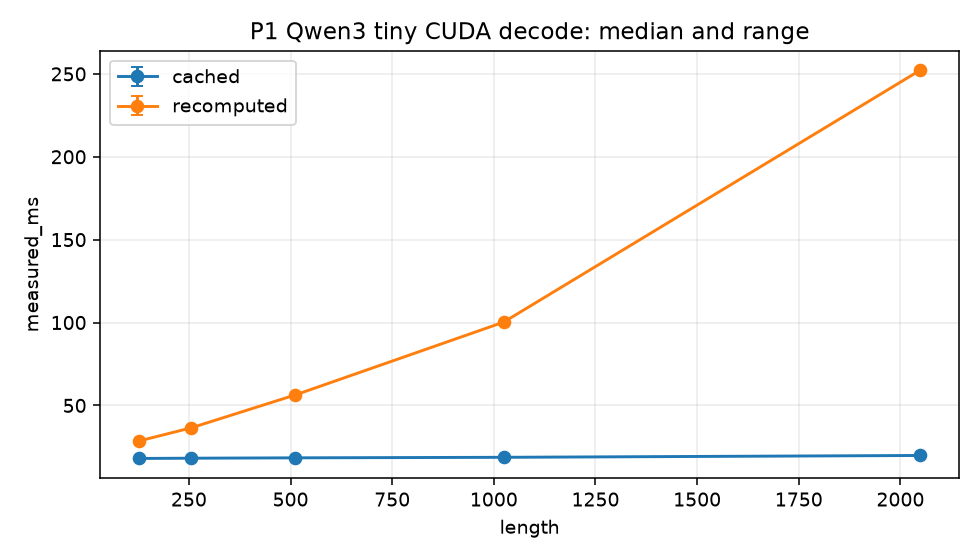

In [12]:
from IPython.display import Image, display

display(Image(filename=str(timing_out / 'latency.png')))


## 5. Continue with full checkpoints

Open [Lab 2: Full Qwen3-8B and Qwen3-32B](lab2.ipynb). It downloads the complete
pinned weights, inspects metadata and every tensor shape, and reuses the custom
blocks to generate full-vocabulary logits. It also carries the full-project cache,
batching, memory, and timing extensions. Keep the checklist below for your final submission.


## 6. Completion checklist and submission

The entry experiment is preparation for the full project. Track both explicitly:

| Goal | Acceptance condition | Evidence |
|---|---|---|
| Entry: timing | Compare cached and recomputed decode at five prefix lengths | Latency chart and saved timing rows |
| Entry: correctness | Reference/custom logits pass the Section 3 comparison | Saved logit comparison |
| Full: weights | 100% trainable tensors mapped for both models; no unexplained missing/unexpected tensors | 8B/32B mapping CSVs and shape audits |
| Full: numerical equivalence | Selected full-vocabulary logits for both models; 8B full, incremental, unequal chunks, mixed batch | Saved comparisons and predeclared BF16 criteria |
| Full: performance | Contexts 128/512/2048, ≥3 repeats; cached/recomputed timings; separate logical/live/reserved memory | Raw timings, memory curves, residual explanation |
| Decision | One measured intervention; explain intercept and slope | 1,200–2,000 word memo, figures, manifest, source revision |

Use the [report and rubric](../../../shared/REPORT.md): correctness 30%, prediction
and explanation 25%, method 20%, implementation understanding 15%, writing and
reproducibility 10%. An explained slowdown can satisfy the project. Label unperformed
hardware work unmeasured and quality intervals pass/fail/inconclusive.

For the oral defense, derive one equation without code, identify a failed hypothesis,
and state whether each figure is measured, modeled, or illustrative. Explain:

- Why is 32B's query stream wider than its residual stream?
- Why does its cache not grow fourfold relative to 8B?
- What could produce plausible text but incorrect chunked-prefill logits?

[Background and readings](../background.md) · [Course home](../../../README.md) ·
[Next chapter: Performance modeling](../../02_performance_model/background.md)
